<a href="https://colab.research.google.com/github/Maheshwar-Pant/ML_lab/blob/main/lab5.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

#Linear Regression and Regularization

This lab session focuses on **Linear Regression and Regularization**.


##Objective
Our primary goal is to:
*   Implement Linear Regression.
*   Thoroughly evaluate its performance using key metrics like Mean Absolute Error (MAE), Mean Squared Error (MSE), Root Mean Squared Error (RMSE), and R².
*   Explore the impact of regularization by applying Ridge and Lasso Regression.
*   Compare the results of these different models both numerically and graphically.



### Dataset
We will be working with the **California Housing dataset**, fetched directly from `sklearn`. This dataset provides information on various districts in California, including median income, average house age, number of rooms, population, geographical coordinates (latitude and longitude), and the crucial target variable: median house value.

### Activities
To achieve our objective, we will follow these steps:

1.  **Data Exploration**: Get familiar with the dataset by inspecting its head, shape, identifying missing values, and reviewing descriptive statistics.
2.  **Data Preparation**: Split the dataset into features and the target variable, followed by an 80/20 train-test split.
3.  **Feature Scaling**: Scale the features using `StandardScaler` to ensure optimal model performance.
4.  **Linear Regression**: Train a `LinearRegression` model on the prepared data.
5.  **Prediction and Evaluation**: Make predictions on the test set and calculate evaluation metrics (MAE, MSE, RMSE, R²).
6.  **Visual Analysis**: Generate an "Actual vs. Predicted" plot and a "Residual Plot" to visually assess model performance.
7.  **Regularization**: Implement `Ridge` regression (with `alpha=1.0`) and `Lasso` regression (with `alpha=0.1`).
8.  **Model Comparison**: Graphically compare the results obtained from the Linear, Ridge, and Lasso regression models.

###1.Import Libraries


In [46]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.datasets import fetch_california_housing
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LinearRegression, Ridge, Lasso
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

##

###2.Load dataset

In [47]:
housing = fetch_california_housing(as_frame=True)
df = housing.frame

###3.Explore dataset

In [48]:
df.head()
df.info()
df.describe()
df.isnull().sum()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 20640 entries, 0 to 20639
Data columns (total 9 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   MedInc       20640 non-null  float64
 1   HouseAge     20640 non-null  float64
 2   AveRooms     20640 non-null  float64
 3   AveBedrms    20640 non-null  float64
 4   Population   20640 non-null  float64
 5   AveOccup     20640 non-null  float64
 6   Latitude     20640 non-null  float64
 7   Longitude    20640 non-null  float64
 8   MedHouseVal  20640 non-null  float64
dtypes: float64(9)
memory usage: 1.4 MB


,0
MedInc,0
HouseAge,0
AveRooms,0
AveBedrms,0
Population,0
AveOccup,0
Latitude,0
Longitude,0
MedHouseVal,0


###4.Split features and target

In [50]:
X=df.drop("MedHouseVal",axis=1)
y=df["MedHouseVal"]


###5.Train-Test Split

In [51]:
X_train ,X_test, y_train ,y_test=train_test_split(X,y,test_size=0.2,random_state=42)

###6. Standardize

In [52]:
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

###7.Linear Regression

In [53]:
model = LinearRegression()
model.fit(X_train_scaled, y_train)
y_pred = model.predict(X_test_scaled)

In [64]:
linear_pred = y_pred

### 8. Evaluate Linear Regression Model Performance

In [57]:
mae=mean_absolute_error(y_test,y_pred)
mse=mean_squared_error(y_test,y_pred)
rmse=np.sqrt(mse)
r2=r2_score(y_test,y_pred)
print(f"Mean Absolute Error (MAE): {mae:.4f}")
print(f"Mean Squared Error (MSE): {mse:.4f}")
print(f"Root Mean Squared Error (RMSE): {rmse:.4f}")
print(f"R-squared (R²): {r2:.4f}")


Mean Absolute Error (MAE): 0.5332
Mean Squared Error (MSE): 0.5559
Root Mean Squared Error (RMSE): 0.7456
R-squared (R²): 0.5758


###9.Ridge

In [58]:
ridge=Ridge(alpha=1.0)
ridge.fit(X_train_scaled,y_train)
ridge_pred=ridge.predict(X_test_scaled)

###10.Lasso

In [59]:
lasso=Lasso(alpha=0.1)
lasso.fit(X_train_scaled,y_train)
lasso_pred=lasso.predict(X_test_scaled)

11.Plot Actual vs Predicted Values

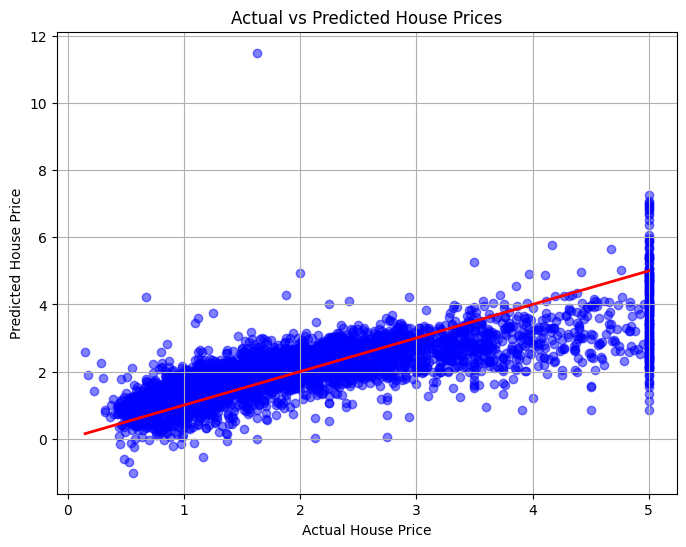

In [61]:
plt.figure(figsize=(8,6))
plt.scatter(y_test,y_pred,color='blue',alpha=0.5)

# Ideal prediction line
plt.plot([y_test.min(), y_test.max()],[y_test.min(),y_test.max()], color='red',linewidth=2)
plt.xlabel("Actual House Price")
plt.ylabel("Predicted House Price")
plt.title("Actual vs Predicted House Prices")
plt.grid(True)
plt.show()

### 12. Residual Plot

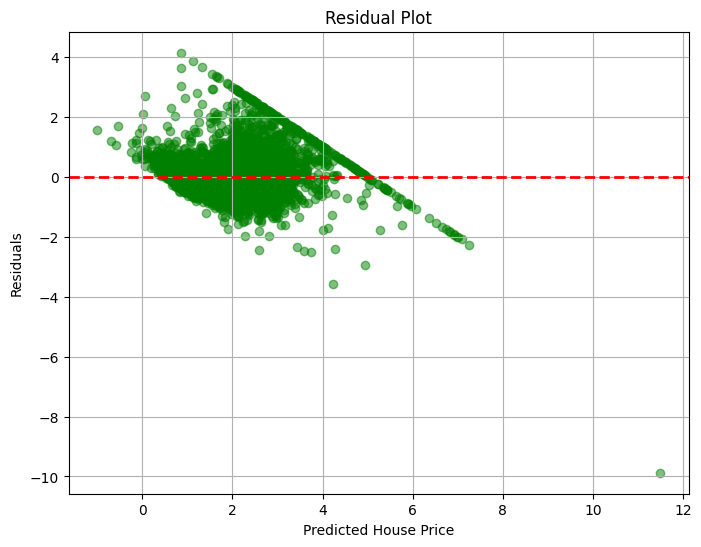

In [66]:
residuals = y_test - linear_pred

plt.figure(figsize=(8, 6))
plt.scatter(linear_pred , residuals, color= 'green',alpha=0.5)
plt.axhline(y=0, color='red', linestyle ='--',linewidth=2)
plt.xlabel("Predicted House Price")
plt.ylabel("Residuals")
plt.title("Residual Plot")
plt.grid(True)
plt.show()

### 13. Compare Linear, Ridge, and Lasso Models Graphically

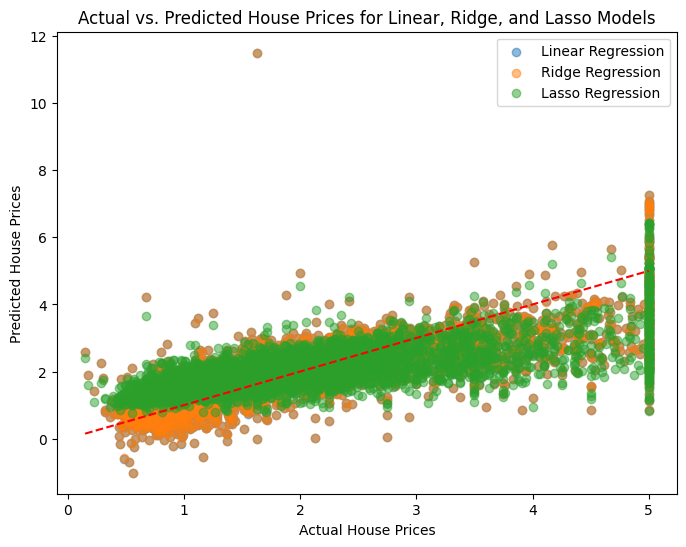

In [67]:
plt.figure(figsize=(8, 6))

plt.scatter(y_test, y_pred, alpha=0.5, label='Linear Regression')
plt.scatter(y_test, ridge_pred, alpha=0.5, label='Ridge Regression')
plt.scatter(y_test, lasso_pred, alpha=0.5, label='Lasso Regression')

plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--')

plt.xlabel('Actual House Prices')
plt.ylabel('Predicted House Prices')
plt.title('Actual vs. Predicted House Prices for Linear, Ridge, and Lasso Models')
plt.legend()

plt.show()